# Setup D -- Holdup-Adjusted Effective Sample Size Proxy for Inclined Pipe NIR Measurement

First-order mechanistic approximation that separates superficial velocity, apparent solids holdup, and estimated local probe velocity for one NIR acquisition.

## Background

Setup D represents an inclined powder-pipe geometry with a wall-mounted diffuse-reflectance NIR probe near the lower side of the pipe. Unlike the static bed in Setup A, the spoon presentations in Setup B, or the wheel-driven renewal in Setup C, this setup treats renewal as a flow-driven process in which fresh powder slides axially past a fixed probe during one acquisition.

The notebook uses a first-order engineering proxy to connect transport-side renewal with optical penetration depth. The reported quantity is a refresh-based proxy effective mass, intended for comparative sensitivity analysis and design-stage interpretation rather than as a validated independent sample mass.

## Objective

This notebook estimates, for Setup D:

- superficial velocity from mass balance
- apparent solids holdup at the probe location
- estimated local powder velocity near the NIR window
- renewal rate in front of the probe during one acquisition
- holdup-adjusted effective sample size proxy for one spectrum
- a separate convective swept-ribbon reference mass and the total process mass crossing the pipe section

The local velocity at the probe is not measured directly in this notebook. It is estimated from mass balance plus an apparent holdup assumption and treated as a sensitivity parameter.

## Theory

### Optical sampling concept

In diffuse reflectance NIR measurements, light enters a powder bed, interacts with particles over a limited depth, and a fraction of the scattered light returns to the detector. The measured spectrum therefore reflects an **optically weighted near-surface region** rather than the entire bulk stream.

For engineering comparisons, the instantaneous optical interaction region is approximated here as a simple cylinder with:

- cross-sectional area equal to the probe footprint
- depth equal to an assumed optical penetration depth

This simplification ignores depth-dependent photon weighting, scattering anisotropy, packing-dependent path-length effects, and spectral absorption details, but it provides a transparent basis for comparative analysis.

### Probe-flow geometry

In Setup D, the probe is mounted in the pipe wall and looks **radially inward**. The powder flows **axially** along the pipe. These directions are perpendicular.

At any instant, the probe sees a shallow optical disc of powder pressed against the wall:

- the disc face is the **probe footprint** with diameter $d_{\mathrm{probe}}$
- the disc depth is the **optical penetration depth** $d_{\mathrm{pen}}$ extending radially into the powder

Because the probe looks perpendicular to the flow, renewal occurs by material sliding **across** the probe window rather than being pushed **into** it. The flow supplies fresh material axially, while the light samples radially.

### Why a renewal model is appropriate

During one acquisition, the probe does not observe a single static neighborhood of powder. Instead, moving material repeatedly replaces the near-wall region in front of the probe. A renewal model is therefore a natural first-order way to connect powder motion to the mass that can contribute to one spectrum.

### Why superficial velocity is still useful

The notebook uses a **superficial bulk velocity** to estimate the renewal driver from throughput, bulk density, and full pipe cross-sectional area. This is a deliberate engineering approximation: the local wall velocity may differ from the cross-sectional average, but the superficial velocity still provides a transparent transport-side baseline for sensitivity analysis and model comparison.

## Input Parameters

Baseline geometry, acquisition settings, holdup assumptions, and sensitivity ranges are defined below. Engineering units are shown in the input block for readability, while calculations use consistent cm, g, and s units.

The baseline worked example uses:

- mass flow = 95 kg/h
- bulk density = 0.4 g/cm^3
- pipe diameter = 65 mm
- probe diameter = 5 mm
- penetration depth = 1.0 mm
- acquisition time = 1.8 s
- nominal apparent holdup fraction = 0.30
- nominal window coverage fraction = 1.0
- nominal wall velocity factor = 1.0
- optical density factor = 1.0

## Imports

In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Erik\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Erik\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Erik\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\Erik\anaconda3\Lib\site-packages

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Erik\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Erik\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Erik\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\Erik\anaconda3\Lib\site-packages

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Erik\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Erik\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Erik\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\Erik\anaconda3\Lib\site-packages

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Erik\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Erik\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Erik\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\Erik\anaconda3\Lib\site-packages

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [2]:
# 7. User-defined parameters (engineering inputs)

pipe_diameter_mm = 65.0
pipe_tilt_deg_from_vertical = 26.5
pipe_total_height_mm = 340.0
pipe_inlet_outlet_displacement_mm = 100.2

probe_diameter_mm = 5.0
acquisition_time_s = 1.8

baseline_mass_flow_kg_h = 95.0
baseline_bulk_density_g_cm3 = 0.4
baseline_penetration_depth_mm = 1.0

nominal_apparent_holdup_fraction = 0.30
nominal_window_coverage_fraction = 1.0
nominal_wall_velocity_factor = 1.0
optical_density_factor = 1.0

holdup_sensitivity_values = [1.0, 0.6, 0.3, 0.15, 0.10, 0.05]
selected_holdups_for_penetration_curves = [1.0, 0.3, 0.1]
penetration_depth_values_mm = np.round(np.arange(0.1, 2.0 + 0.1, 0.1), 1)

subscan_time_s = 0.012
subscan_count = 150

## Velocity framework: superficial velocity, holdup, and local probe velocity

The mass flow gives a superficial velocity, $v_{sup}$, by dividing throughput by the product of flow bulk density and the full pipe cross-sectional area. This value is useful, but it is not automatically the velocity seen by the wall-mounted NIR probe.

In a completely filled pipe, $v_{sup}$ would equal the cross-sectional mean axial powder velocity. In a partially occupied gravity-flow pipe, the same mass flow passes through a smaller moving-powder area, so the occupied-region velocity is higher than the superficial velocity. The notebook represents this with an apparent cross-sectional solids holdup, $\phi_A$:

$$
v_{occ}=\frac{v_{sup}}{\phi_A}
$$

The probe-region velocity used for renewal is then:

$$
v_{probe}=k_{wall}\,\frac{v_{sup}}{\phi_A}
$$

Here $k_{wall}$ is an optional wall velocity factor. Values below 1 represent slower wall-adjacent powder; values above 1 represent a faster local stream intersecting the probe. The nominal model uses $\phi_A=0.30$ and $k_{wall}=1.0$, but $\phi_A$ is treated as a sensitivity parameter rather than a measured constant.

## Practical note on velocity estimation without high-speed imaging

The true local powder velocity at the NIR window is not measured in the present setup. The preferred evidence would be high-speed video, particle tracking, or a dedicated time-of-flight measurement close to the probe. Without those data, the notebook does not claim direct validation of $v_{probe}$.

Literature powder velocities are also not used as the primary basis for the calculation. Granular flow velocity depends strongly on powder properties, wall friction, aeration state, fill level, pipe geometry, and local flow regime, so a generic literature value would be hard to defend for this specific probe location.

The best available framework is therefore mass-balance based: known throughput defines $v_{sup}$, apparent holdup converts it to an occupied-region velocity, and the wall factor optionally adjusts that estimate at the NIR window. This makes the local velocity estimate explicit and auditable, while the holdup sensitivity table communicates the uncertainty caused by the missing direct velocity measurement.

## Assumptions

- Powder density used for the flow calculation represents the relevant dynamic bulk density unless otherwise specified.
- The NIR optical density is initially assumed equal to the flow bulk density.
- The nominal apparent holdup fraction is 0.30, based on visual engineering assessment.
- The actual holdup is uncertain and must be explored by sensitivity analysis.
- The nominal window coverage fraction is 1.0.
- The nominal wall velocity factor is 1.0.
- The model estimates an apparent local velocity, not a directly measured particle velocity.
- The ESS proxy describes near-wall material contributing to the NIR signal, not the full mass passing through the pipe.

## Governing Equations and Proxy Definitions

Internal units used throughout the notebook are cm, g, and s. Reported outputs are shown in practical units (mm, mg, g, kg/h) as noted.

### Flow and velocity model

Mass-flow conversion:

$$
\dot{m}_{g/s} = \dot{m}_{kg/h}\cdot\frac{1000}{3600}
$$

Pipe area:

$$
A_{pipe} = \pi\left(\frac{d_{pipe}}{2}\right)^2
$$

Superficial velocity from mass balance:

$$
v_{sup} = \frac{\dot{m}}{\rho_{flow}\,A_{pipe}}
$$

Apparent occupied-region velocity:

$$
v_{occ} = \frac{v_{sup}}{\phi_A}
$$

Estimated local probe velocity with optional wall correction:

$$
v_{probe} = k_{wall}\,\frac{v_{sup}}{\phi_A}
$$

where $\phi_A$ is the apparent moving-powder holdup fraction, and $k_{wall}$ is an empirical wall-velocity factor.

### Optical mass and renewal

Optical density model:

$$
\rho_{opt} = \rho_{flow}\cdot f_{opt}
$$

Probe area:

$$
A_{probe} = \pi\left(\frac{d_{probe}}{2}\right)^2
$$

Instantaneous optical mass:

$$
m_{inst} = \rho_{opt}\,A_{probe}\,d_{pen}
$$

Renewal factor during one acquisition:

$$
N_{refresh} = \frac{v_{probe}\,t_{acq}\,C_{window}}{d_{probe}}
$$

Holdup-adjusted ESS proxy:

$$
m_{eff,proxy} = m_{inst}\,N_{refresh}
$$

Convective swept-ribbon reference mass (reported separately from ESS proxy):

$$
m_{swept} = \rho_{opt}\,A_{probe}\left(d_{pen}+v_{probe}\,t_{acq}\,C_{window}\right)
$$

Total process mass passing the full pipe cross-section during one acquisition:

$$
m_{process,total} = \dot{m}_{g/s}\,t_{acq}
$$

Interpretation boundary:

- $m_{process,total}$ is the total process mass crossing the axial location.
- The NIR signal represents only a near-wall optical subset of that process mass.
- Local velocity is estimated from mass balance and apparent holdup; it is not directly measured.

## Schematic of Probe Geometry and Renewal Bookkeeping

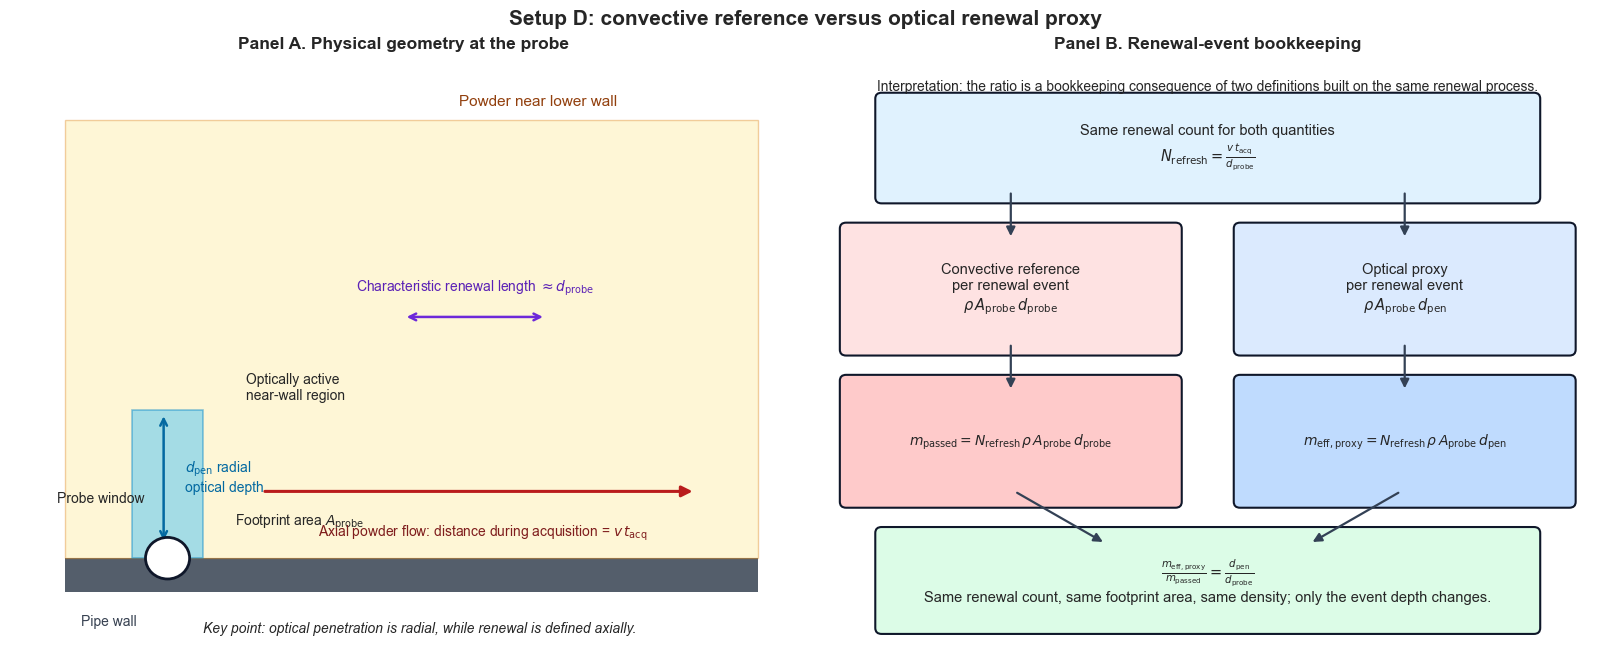

In [3]:
# Two-panel schematic: physical geometry and renewal-event bookkeeping
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch, FancyBboxPatch

fig_setup_d_schematic, axes = plt.subplots(1, 2, figsize=(16, 6.5), constrained_layout=True)
fig_setup_d_schematic.suptitle(
    'Setup D: convective reference versus optical renewal proxy',
    fontsize=15,
    fontweight='bold',
)

for ax in axes:
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.axis('off')

# Panel A: physical geometry at the probe
ax = axes[0]
ax.set_title('Panel A. Physical geometry at the probe', fontsize=12.5, fontweight='bold')

# Pipe wall and powder region
ax.add_patch(Rectangle((0.7, 0.8), 8.8, 0.45, facecolor='#4b5563', edgecolor='none', alpha=0.95))
ax.text(0.9, 0.35, 'Pipe wall', fontsize=10, color='#374151')
ax.add_patch(Rectangle((0.7, 1.25), 8.8, 5.9, facecolor='#fde68a', edgecolor='#d97706', linewidth=1.0, alpha=0.35))
ax.text(6.7, 7.35, 'Powder near lower wall', fontsize=11, ha='center', color='#92400e')

# Probe window at the lower wall
probe_center = (2.0, 1.25)
ax.add_patch(Circle(probe_center, 0.28, facecolor='white', edgecolor='#0f172a', linewidth=2.0, zorder=5))
ax.text(1.15, 2.0, 'Probe window', fontsize=10, ha='center')
ax.text(2.85, 1.7, r'Footprint area $A_{\mathrm{probe}}$', fontsize=10, ha='left')

# Optical near-wall region
ax.add_patch(Rectangle((1.55, 1.25), 0.9, 2.0, facecolor='#38bdf8', edgecolor='#0284c7', linewidth=1.2, alpha=0.45))
ax.text(3.0, 3.55, 'Optically active\nnear-wall region'.replace('\\n', '\n'), fontsize=10, va='center')

# Radial penetration arrow
ax.add_patch(FancyArrowPatch((1.95, 1.45), (1.95, 3.2), arrowstyle='<->', mutation_scale=12, linewidth=1.8, color='#0369a1'))
ax.text(2.22, 2.35, r'$d_{\mathrm{pen}}$ radial' + '\n' + 'optical depth', fontsize=10, color='#0369a1', va='center')

# Axial flow arrow and travel distance
ax.add_patch(FancyArrowPatch((3.2, 2.15), (8.7, 2.15), arrowstyle='-|>', mutation_scale=16, linewidth=2.2, color='#b91c1c'))
ax.text(6.0, 1.55, r'Axial powder flow: distance during acquisition = $v\,t_{\mathrm{acq}}$', fontsize=10, color='#7f1d1d', ha='center')

# Characteristic renewal length
ax.add_patch(FancyArrowPatch((5.0, 4.5), (6.8, 4.5), arrowstyle='<->', mutation_scale=12, linewidth=1.8, color='#6d28d9'))
ax.text(5.9, 4.85, r'Characteristic renewal length $\approx d_{\mathrm{probe}}$', fontsize=10, color='#5b21b6', ha='center')

ax.text(
    5.2,
    0.25,
    'Key point: optical penetration is radial, while renewal is defined axially.',
    fontsize=10,
    ha='center',
    style='italic',
)

# Panel B: bookkeeping for one renewal event
ax = axes[1]
ax.set_title('Panel B. Renewal-event bookkeeping', fontsize=12.5, fontweight='bold')


def add_box(ax, x, y, width, height, text, facecolor, edgecolor='#0f172a', fontsize=10):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle='round,pad=0.22,rounding_size=0.08',
        linewidth=1.5,
        facecolor=facecolor,
        edgecolor=edgecolor,
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y + height / 2, text, ha='center', va='center', fontsize=fontsize)
    return box

add_box(
    ax,
    1.0,
    6.25,
    8.0,
    1.05,
    'Same renewal count for both quantities\n' + r'$N_{\mathrm{refresh}} = \frac{v\,t_{\mathrm{acq}}}{d_{\mathrm{probe}}}$',
    '#e0f2fe',
    fontsize=10.5,
)

add_box(
    ax,
    0.55,
    4.2,
    3.9,
    1.35,
    'Convective reference\nper renewal event\n' + r'$\rho\,A_{\mathrm{probe}}\,d_{\mathrm{probe}}$',
    '#fee2e2',
    fontsize=10.5,
)
add_box(
    ax,
    5.55,
    4.2,
    3.9,
    1.35,
    'Optical proxy\nper renewal event\n' + r'$\rho\,A_{\mathrm{probe}}\,d_{\mathrm{pen}}$',
    '#dbeafe',
    fontsize=10.5,
)

add_box(
    ax,
    0.55,
    2.15,
    3.9,
    1.35,
    r'$m_{\mathrm{passed}} = N_{\mathrm{refresh}}\,\rho\,A_{\mathrm{probe}}\,d_{\mathrm{probe}}$',
    '#fecaca',
    fontsize=10,
)
add_box(
    ax,
    5.55,
    2.15,
    3.9,
    1.35,
    r'$m_{\mathrm{eff,proxy}} = N_{\mathrm{refresh}}\,\rho\,A_{\mathrm{probe}}\,d_{\mathrm{pen}}$',
    '#bfdbfe',
    fontsize=10,
)

add_box(
    ax,
    1.0,
    0.45,
    8.0,
    1.0,
    r'$\frac{m_{\mathrm{eff,proxy}}}{m_{\mathrm{passed}}} = \frac{d_{\mathrm{pen}}}{d_{\mathrm{probe}}}$'
    + '\n'
    + 'Same renewal count, same footprint area, same density; only the event depth changes.',
    '#dcfce7',
    fontsize=10.5,
)

for start, end in [
    ((2.5, 6.2), (2.5, 5.55)),
    ((7.5, 6.2), (7.5, 5.55)),
    ((2.5, 4.15), (2.5, 3.5)),
    ((7.5, 4.15), (7.5, 3.5)),
    ((2.55, 2.15), (3.7, 1.45)),
    ((7.45, 2.15), (6.3, 1.45)),
]:
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle='-|>', mutation_scale=13, linewidth=1.6, color='#334155'))

ax.text(
    5.0,
    7.55,
    'Interpretation: the ratio is a bookkeeping consequence of two definitions built on the same renewal process.',
    fontsize=10,
    ha='center',
)

plt.show()

## Helper Functions

In [4]:
# 8. Helper functions

def _validate_positive(value, name):
    if np.any(np.asarray(value) <= 0):
        raise ValueError(f"{name} must be positive; received {value!r}.")


def _validate_fraction(value, name):
    value_array = np.asarray(value)
    if np.any(value_array <= 0) or np.any(value_array > 1):
        raise ValueError(f"{name} must be in (0, 1]; received {value!r}.")


def mm_to_cm(mm):
    """Convert millimeters to centimeters."""
    _validate_positive(mm, "mm")
    return mm / 10.0


def kg_h_to_g_s(kg_h):
    """Convert mass flow from kg/h to g/s."""
    _validate_positive(kg_h, "kg_h")
    return kg_h * 1000.0 / 3600.0


def pipe_area(pipe_diameter_cm):
    """Pipe cross-sectional area [cm^2] from internal diameter [cm]."""
    _validate_positive(pipe_diameter_cm, "pipe_diameter_cm")
    return math.pi * (pipe_diameter_cm / 2.0) ** 2


def probe_area(probe_diameter_cm):
    """Probe window area [cm^2] from window diameter [cm]."""
    _validate_positive(probe_diameter_cm, "probe_diameter_cm")
    return math.pi * (probe_diameter_cm / 2.0) ** 2


def superficial_velocity(mdot_kg_h, rho_flow_g_cm3, pipe_diameter_cm):
    """Superficial velocity [cm/s] from mass balance using full pipe area."""
    _validate_positive(rho_flow_g_cm3, "rho_flow_g_cm3")
    return kg_h_to_g_s(mdot_kg_h) / (rho_flow_g_cm3 * pipe_area(pipe_diameter_cm))


def local_velocity_from_holdup(v_sup_cm_s, phi_A, wall_velocity_factor=1.0):
    """Estimated local probe velocity [cm/s] from holdup and wall factor."""
    _validate_positive(v_sup_cm_s, "v_sup_cm_s")
    _validate_fraction(phi_A, "phi_A")
    _validate_positive(wall_velocity_factor, "wall_velocity_factor")
    return wall_velocity_factor * v_sup_cm_s / phi_A


def optical_density(rho_flow_g_cm3, optical_density_factor=1.0):
    """Optical-region density [g/cm^3], default equal to flow bulk density."""
    _validate_positive(rho_flow_g_cm3, "rho_flow_g_cm3")
    _validate_positive(optical_density_factor, "optical_density_factor")
    return rho_flow_g_cm3 * optical_density_factor


def instantaneous_optical_mass(rho_opt_g_cm3, probe_diameter_cm, penetration_depth_cm):
    """Instantaneous optical mass [g] near the probe window."""
    _validate_positive(rho_opt_g_cm3, "rho_opt_g_cm3")
    _validate_positive(penetration_depth_cm, "penetration_depth_cm")
    return rho_opt_g_cm3 * probe_area(probe_diameter_cm) * penetration_depth_cm


def renewal_factor(v_probe_cm_s, acquisition_time_s, window_coverage_fraction, probe_diameter_cm):
    """Renewal factor [-] during acquisition at probe scale."""
    _validate_positive(v_probe_cm_s, "v_probe_cm_s")
    _validate_positive(acquisition_time_s, "acquisition_time_s")
    _validate_fraction(window_coverage_fraction, "window_coverage_fraction")
    _validate_positive(probe_diameter_cm, "probe_diameter_cm")
    return v_probe_cm_s * acquisition_time_s * window_coverage_fraction / probe_diameter_cm


def holdup_adjusted_ess_proxy(m_inst_g, n_refresh):
    """Holdup-adjusted ESS proxy [g] for one spectrum."""
    _validate_positive(m_inst_g, "m_inst_g")
    _validate_positive(n_refresh, "n_refresh")
    return m_inst_g * n_refresh


def convective_swept_ribbon_mass(
    rho_opt_g_cm3,
    penetration_depth_cm,
    probe_diameter_cm,
    v_probe_cm_s,
    acquisition_time_s,
    window_coverage_fraction,
):
    """Convective swept-ribbon reference mass [g], reported separately from ESS proxy."""
    _validate_positive(rho_opt_g_cm3, "rho_opt_g_cm3")
    _validate_positive(penetration_depth_cm, "penetration_depth_cm")
    _validate_positive(probe_diameter_cm, "probe_diameter_cm")
    _validate_positive(v_probe_cm_s, "v_probe_cm_s")
    _validate_positive(acquisition_time_s, "acquisition_time_s")
    _validate_fraction(window_coverage_fraction, "window_coverage_fraction")

    area_probe_cm2 = probe_area(probe_diameter_cm)
    travel_distance_cm = v_probe_cm_s * acquisition_time_s * window_coverage_fraction
    return rho_opt_g_cm3 * area_probe_cm2 * (penetration_depth_cm + travel_distance_cm)


def total_process_mass_during_acquisition(mdot_kg_h, acquisition_time_s):
    """Total process mass [g] crossing the full pipe cross-section during acquisition."""
    _validate_positive(mdot_kg_h, "mdot_kg_h")
    _validate_positive(acquisition_time_s, "acquisition_time_s")
    return kg_h_to_g_s(mdot_kg_h) * acquisition_time_s

## Single-Case Worked Example

The baseline worked example uses:

- mass flow = 95 kg/h
- bulk density = 0.4 g/cm^3
- pipe diameter = 65 mm
- probe diameter = 5 mm
- penetration depth = 1.0 mm
- acquisition time = 1.8 s
- apparent holdup fraction = 0.30
- wall velocity factor = 1.0
- window coverage fraction = 1.0
- optical density factor = 1.0

This worked example explicitly distinguishes superficial velocity, estimated local probe velocity, renewal rate, ESS proxy, convective reference mass, and total process mass at the same axial location.

In [5]:
pipe_diameter_cm = mm_to_cm(pipe_diameter_mm)
probe_diameter_cm = mm_to_cm(probe_diameter_mm)
penetration_depth_cm = mm_to_cm(baseline_penetration_depth_mm)

v_sup_cm_s = superficial_velocity(
    baseline_mass_flow_kg_h,
    baseline_bulk_density_g_cm3,
    pipe_diameter_cm,
)
v_probe_cm_s = local_velocity_from_holdup(
    v_sup_cm_s,
    nominal_apparent_holdup_fraction,
    wall_velocity_factor=nominal_wall_velocity_factor,
)
rho_opt_g_cm3 = optical_density(
    baseline_bulk_density_g_cm3,
    optical_density_factor=optical_density_factor,
)

m_inst_g = instantaneous_optical_mass(
    rho_opt_g_cm3,
    probe_diameter_cm,
    penetration_depth_cm,
)
travel_distance_cm = v_probe_cm_s * acquisition_time_s
n_refresh = renewal_factor(
    v_probe_cm_s,
    acquisition_time_s,
    nominal_window_coverage_fraction,
    probe_diameter_cm,
)
m_eff_proxy_g = holdup_adjusted_ess_proxy(m_inst_g, n_refresh)
m_swept_g = convective_swept_ribbon_mass(
    rho_opt_g_cm3,
    penetration_depth_cm,
    probe_diameter_cm,
    v_probe_cm_s,
    acquisition_time_s,
    nominal_window_coverage_fraction,
)
total_process_mass_g = total_process_mass_during_acquisition(
    baseline_mass_flow_kg_h,
    acquisition_time_s,
)

worked_example_summary_df = pd.DataFrame(
    [
        {"Metric": "mass flow", "Value": baseline_mass_flow_kg_h, "Unit": "kg/h"},
        {"Metric": "bulk density", "Value": baseline_bulk_density_g_cm3, "Unit": "g/cm^3"},
        {"Metric": "pipe diameter", "Value": pipe_diameter_mm, "Unit": "mm"},
        {"Metric": "probe diameter", "Value": probe_diameter_mm, "Unit": "mm"},
        {"Metric": "penetration depth", "Value": baseline_penetration_depth_mm, "Unit": "mm"},
        {"Metric": "acquisition time", "Value": acquisition_time_s, "Unit": "s"},
        {"Metric": "superficial velocity", "Value": v_sup_cm_s, "Unit": "cm/s"},
        {"Metric": "apparent holdup fraction", "Value": nominal_apparent_holdup_fraction, "Unit": "-"},
        {"Metric": "wall velocity factor", "Value": nominal_wall_velocity_factor, "Unit": "-"},
        {"Metric": "window coverage fraction", "Value": nominal_window_coverage_fraction, "Unit": "-"},
        {"Metric": "estimated local probe velocity", "Value": v_probe_cm_s, "Unit": "cm/s"},
        {"Metric": "travel distance during acquisition", "Value": travel_distance_cm, "Unit": "cm"},
        {"Metric": "instantaneous optical mass", "Value": m_inst_g * 1000.0, "Unit": "mg"},
        {"Metric": "renewal factor", "Value": n_refresh, "Unit": "-"},
        {"Metric": "holdup-adjusted ESS proxy", "Value": m_eff_proxy_g * 1000.0, "Unit": "mg"},
        {"Metric": "convective swept-ribbon reference mass", "Value": m_swept_g, "Unit": "g"},
        {
            "Metric": "total process mass passing pipe cross-section during acquisition",
            "Value": total_process_mass_g,
            "Unit": "g",
        },
    ]
)

worked_example_summary_df["Value"] = worked_example_summary_df["Value"].map(lambda x: float(f"{x:.6g}"))
worked_example_summary_df

# Quality checks for baseline expectations
assert np.isclose(v_sup_cm_s, 1.99, rtol=0.01)
assert np.isclose(v_probe_cm_s, 6.63, rtol=0.02)
assert np.isclose(m_inst_g * 1000.0, 7.85, rtol=0.02)
assert np.isclose(m_eff_proxy_g * 1000.0, 187.0, rtol=0.03)
assert np.isclose(m_swept_g, 0.94, rtol=0.05)
assert np.isclose(total_process_mass_g, 47.5, rtol=0.01)

## Holdup Sensitivity Simulation

The holdup sensitivity table uses the requested apparent holdup values:

- 1.0
- 0.6
- 0.3
- 0.15
- 0.10
- 0.05

For each holdup value, the notebook reports superficial velocity, estimated local probe velocity, travel distance, renewal factor, ESS proxy, and convective swept-ribbon reference mass.

In [6]:
holdup_records = []

for phi_A in holdup_sensitivity_values:
    v_probe_phi_cm_s = local_velocity_from_holdup(
        v_sup_cm_s,
        phi_A,
        wall_velocity_factor=nominal_wall_velocity_factor,
    )
    distance_phi_cm = v_probe_phi_cm_s * acquisition_time_s
    n_refresh_phi = renewal_factor(
        v_probe_phi_cm_s,
        acquisition_time_s,
        nominal_window_coverage_fraction,
        probe_diameter_cm,
    )
    m_eff_phi_g = holdup_adjusted_ess_proxy(m_inst_g, n_refresh_phi)
    m_swept_phi_g = convective_swept_ribbon_mass(
        rho_opt_g_cm3,
        penetration_depth_cm,
        probe_diameter_cm,
        v_probe_phi_cm_s,
        acquisition_time_s,
        nominal_window_coverage_fraction,
    )

    holdup_records.append(
        {
            "apparent_holdup_fraction": phi_A,
            "superficial_velocity_cm_s": v_sup_cm_s,
            "local_probe_velocity_cm_s": v_probe_phi_cm_s,
            "travel_distance_cm": distance_phi_cm,
            "renewal_factor": n_refresh_phi,
            "ess_proxy_mg": m_eff_phi_g * 1000.0,
            "convective_swept_ribbon_mass_g": m_swept_phi_g,
        }
    )

holdup_sensitivity_df = pd.DataFrame(holdup_records)
holdup_sensitivity_df = holdup_sensitivity_df.sort_values("apparent_holdup_fraction", ascending=False).reset_index(drop=True)

penetration_records = []
for phi_A in selected_holdups_for_penetration_curves:
    v_probe_phi_cm_s = local_velocity_from_holdup(
        v_sup_cm_s,
        phi_A,
        wall_velocity_factor=nominal_wall_velocity_factor,
    )
    n_refresh_phi = renewal_factor(
        v_probe_phi_cm_s,
        acquisition_time_s,
        nominal_window_coverage_fraction,
        probe_diameter_cm,
    )
    for penetration_mm in penetration_depth_values_mm:
        penetration_cm = mm_to_cm(float(penetration_mm))
        m_inst_pen_g = instantaneous_optical_mass(
            rho_opt_g_cm3,
            probe_diameter_cm,
            penetration_cm,
        )
        m_eff_pen_g = holdup_adjusted_ess_proxy(m_inst_pen_g, n_refresh_phi)
        penetration_records.append(
            {
                "apparent_holdup_fraction": phi_A,
                "penetration_depth_mm": float(penetration_mm),
                "ess_proxy_mg": m_eff_pen_g * 1000.0,
            }
        )

penetration_sweep_df = pd.DataFrame(penetration_records)

holdup_grid = np.linspace(0.05, 1.0, 80)
penetration_grid_mm = np.linspace(0.1, 2.0, 80)
H, P = np.meshgrid(holdup_grid, penetration_grid_mm)

m_inst_grid_g = instantaneous_optical_mass(rho_opt_g_cm3, probe_diameter_cm, P / 10.0)
v_probe_grid_cm_s = local_velocity_from_holdup(v_sup_cm_s, H, wall_velocity_factor=nominal_wall_velocity_factor)
n_refresh_grid = renewal_factor(
    v_probe_grid_cm_s,
    acquisition_time_s,
    nominal_window_coverage_fraction,
    probe_diameter_cm,
)
ess_grid_mg = holdup_adjusted_ess_proxy(m_inst_grid_g, n_refresh_grid) * 1000.0

## Interpretation of Holdup Sensitivity Table

The table below should be read as a sensitivity analysis, not as direct velocity measurement. Superficial velocity is fixed by throughput, density, and full pipe area. Lower apparent holdup means the same mass flow is carried through a smaller occupied region, so the estimated local probe velocity and renewal factor increase.

In [7]:
holdup_sensitivity_display_df = holdup_sensitivity_df.copy()
for col in [
    "superficial_velocity_cm_s",
    "local_probe_velocity_cm_s",
    "travel_distance_cm",
    "renewal_factor",
    "ess_proxy_mg",
    "convective_swept_ribbon_mass_g",
]:
    holdup_sensitivity_display_df[col] = holdup_sensitivity_display_df[col].map(lambda x: float(f"{x:.4f}"))

holdup_sensitivity_display_df

,apparent_holdup_fraction,superficial_velocity_cm_s,local_probe_velocity_cm_s,travel_distance_cm,renewal_factor,ess_proxy_mg,convective_swept_ribbon_mass_g
0,1.0000,1.9881,1.9881,3.5786,7.1573,56.2130,0.2889
1,0.6000,1.9881,3.3135,5.9644,11.9288,93.6884,0.4763
2,0.3000,1.9881,6.6271,11.9288,23.8575,187.3767,0.9447
3,0.1500,1.9881,13.2542,23.8575,47.7151,374.7535,1.8816
4,0.1000,1.9881,19.8813,35.7863,71.5726,562.1302,2.8185
5,0.0500,1.9881,39.7626,71.5726,143.1453,"1,124.2604",5.6292


In [8]:
penetration_pivot_df = penetration_sweep_df.pivot(
    index="penetration_depth_mm",
    columns="apparent_holdup_fraction",
    values="ess_proxy_mg",
)
penetration_pivot_df.head()

apparent_holdup_fraction,0.1000,0.3000,1.0000
penetration_depth_mm,,,
0.1000,56.2130,18.7377,5.6213
0.2000,112.4260,37.4753,11.2426
0.3000,168.6391,56.2130,16.8639
0.4000,224.8521,74.9507,22.4852
0.5000,281.0651,93.6884,28.1065


## Figures

The figures are ordered from holdup-based velocity assumptions to ESS consequences.

## Plot 1: Estimated Local Probe Velocity vs Apparent Holdup Fraction

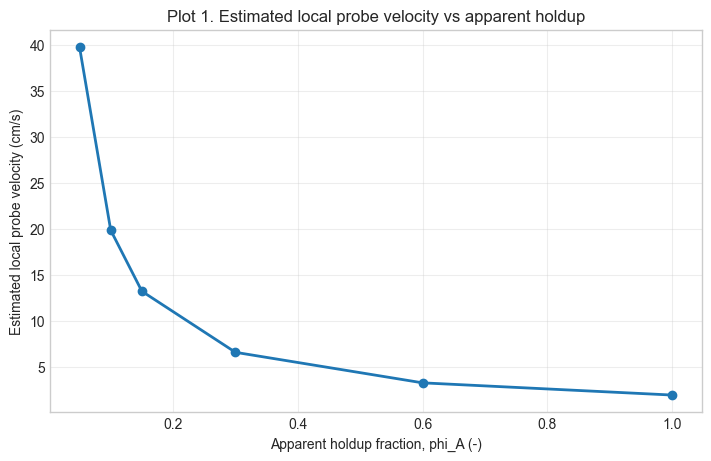

In [9]:
fig_setup_d_plot_01, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot_df = holdup_sensitivity_df.sort_values("apparent_holdup_fraction")
ax.plot(
    plot_df["apparent_holdup_fraction"],
    plot_df["local_probe_velocity_cm_s"],
    marker="o",
    linewidth=2,
)
ax.set_title("Plot 1. Estimated local probe velocity vs apparent holdup")
ax.set_xlabel("Apparent holdup fraction, phi_A (-)")
ax.set_ylabel("Estimated local probe velocity (cm/s)")
ax.grid(True, alpha=0.35)
plt.show()

## Plot 2: Renewal Factor vs Apparent Holdup Fraction

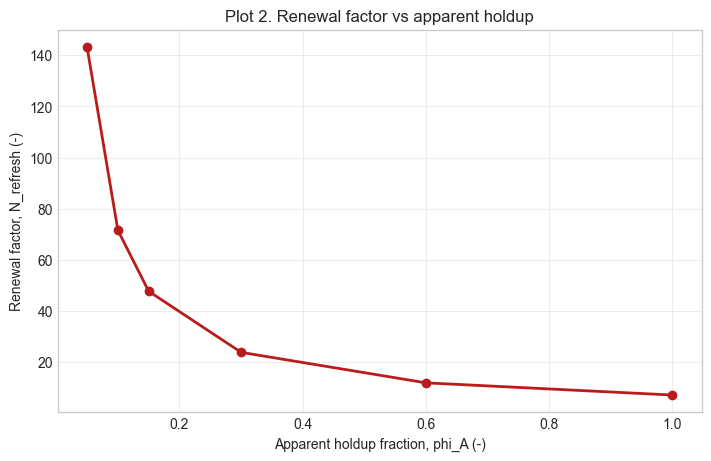

In [10]:
fig_setup_d_plot_02, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot_df = holdup_sensitivity_df.sort_values("apparent_holdup_fraction")
ax.plot(
    plot_df["apparent_holdup_fraction"],
    plot_df["renewal_factor"],
    marker="o",
    linewidth=2,
    color="#b91c1c",
)
ax.set_title("Plot 2. Renewal factor vs apparent holdup")
ax.set_xlabel("Apparent holdup fraction, phi_A (-)")
ax.set_ylabel("Renewal factor, N_refresh (-)")
ax.grid(True, alpha=0.35)
plt.show()

## Plot 3: Holdup-Adjusted ESS Proxy vs Apparent Holdup Fraction

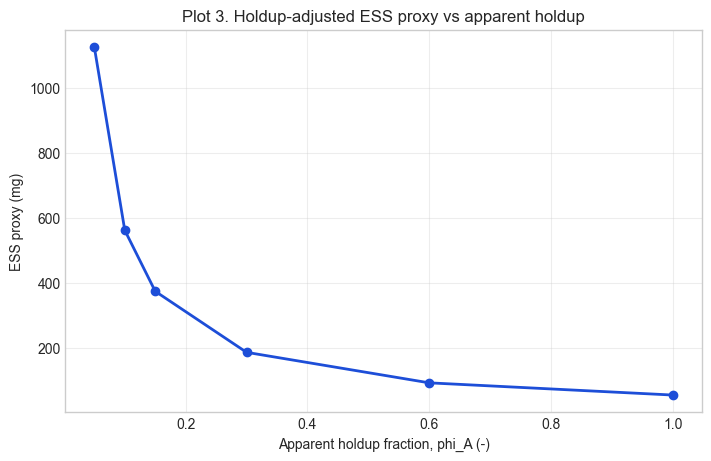

In [11]:
fig_setup_d_plot_03, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot_df = holdup_sensitivity_df.sort_values("apparent_holdup_fraction")
ax.plot(
    plot_df["apparent_holdup_fraction"],
    plot_df["ess_proxy_mg"],
    marker="o",
    linewidth=2,
    color="#1d4ed8",
)
ax.set_title("Plot 3. Holdup-adjusted ESS proxy vs apparent holdup")
ax.set_xlabel("Apparent holdup fraction, phi_A (-)")
ax.set_ylabel("ESS proxy (mg)")
ax.grid(True, alpha=0.35)
plt.show()

## Plot 4: ESS Proxy vs Penetration Depth (Selected Holdups)

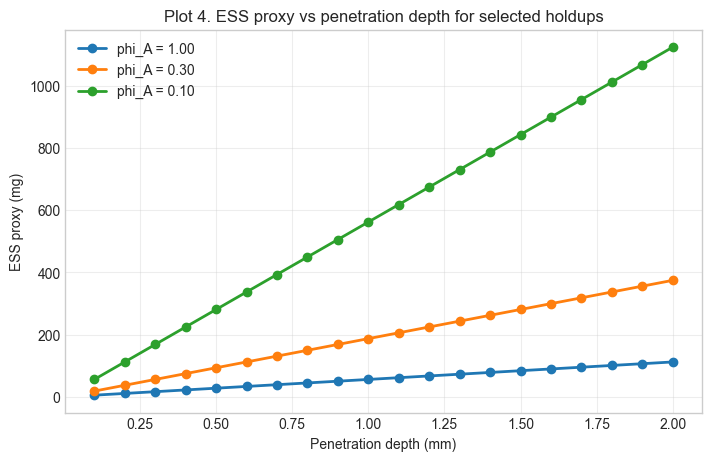

In [12]:
fig_setup_d_plot_04, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
for phi_A in selected_holdups_for_penetration_curves:
    subset = penetration_sweep_df[np.isclose(penetration_sweep_df["apparent_holdup_fraction"], phi_A)]
    ax.plot(
        subset["penetration_depth_mm"],
        subset["ess_proxy_mg"],
        marker="o",
        linewidth=2,
        label=f"phi_A = {phi_A:.2f}",
    )
ax.set_title("Plot 4. ESS proxy vs penetration depth for selected holdups")
ax.set_xlabel("Penetration depth (mm)")
ax.set_ylabel("ESS proxy (mg)")
ax.legend()
ax.grid(True, alpha=0.35)
plt.show()

## Plot 5: Contour of ESS Proxy vs Penetration Depth and Holdup

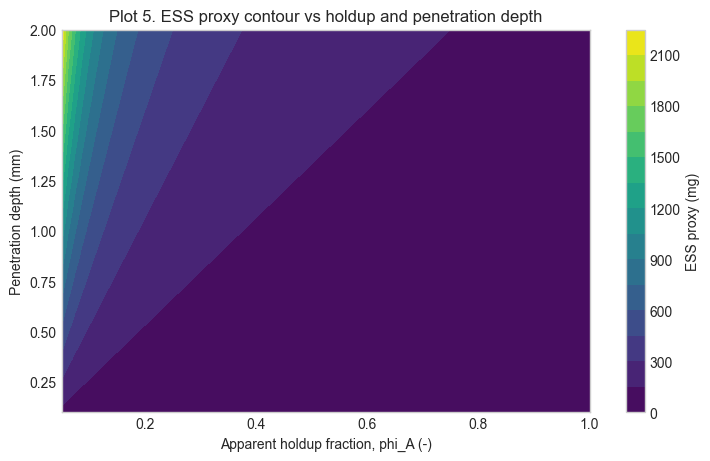

In [13]:
fig_setup_d_plot_05, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
contour = ax.contourf(H, P, ess_grid_mg, levels=20, cmap="viridis")
ax.set_title("Plot 5. ESS proxy contour vs holdup and penetration depth")
ax.set_xlabel("Apparent holdup fraction, phi_A (-)")
ax.set_ylabel("Penetration depth (mm)")
fig_setup_d_plot_05.colorbar(contour, ax=ax, label="ESS proxy (mg)")
plt.show()

## Plot 6: Mass Scale Comparison for the Baseline Case

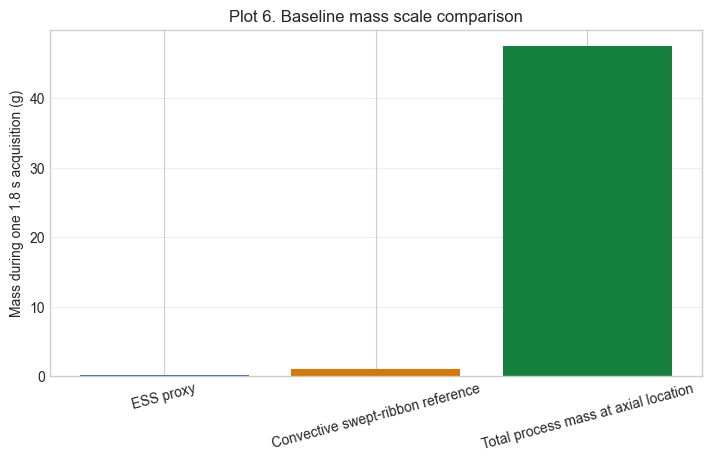

In [14]:
fig_setup_d_plot_06, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
comparison_df = pd.DataFrame(
    {
        "Quantity": [
            "ESS proxy",
            "Convective swept-ribbon reference",
            "Total process mass at axial location",
        ],
        "Mass_g": [m_eff_proxy_g, m_swept_g, total_process_mass_g],
    }
)
ax.bar(comparison_df["Quantity"], comparison_df["Mass_g"], color=["#2563eb", "#d97706", "#15803d"])
ax.set_title("Plot 6. Baseline mass scale comparison")
ax.set_ylabel("Mass during one 1.8 s acquisition (g)")
ax.tick_params(axis="x", rotation=15)
ax.grid(True, axis="y", alpha=0.35)
plt.show()

## Results Interpretation

The full-pipe superficial-velocity case should be interpreted as a conservative low-velocity reference. Lower apparent holdup values produce higher estimated local velocities because the same process mass flow is transported through a smaller occupied region of the pipe. As a result, powder renews more rapidly in front of the NIR window and the estimated one-spectrum ESS proxy increases approximately in proportion to 1/phi_A, provided optical density, window coverage, and wall velocity correction remain unchanged. The nominal 30% holdup case should therefore be viewed as a pragmatic engineering estimate, while the holdup sensitivity range communicates the uncertainty in the unmeasured local velocity.

For the baseline case, total process mass passing the full pipe cross-section during one 1.8 s spectrum is about 47.5 g, while the NIR proxy quantities are much smaller because they represent a near-wall optical subset.

## Limitations

- The local velocity at the NIR window is not directly measured.
- Apparent holdup is an assumed parameter informed by engineering judgment.
- Wall velocity factor and window coverage fraction are not independently measured in this notebook.
- The optical depth is modeled as a uniform effective penetration depth.
- The ESS quantity reported here is a mechanistic proxy for near-wall contributing mass, not a validated statistical ESS metric.

## Next Logical Extensions

Natural next steps for reducing model uncertainty are:

- acquire direct probe-region velocity evidence and use it to constrain $\phi_A$ and $k_{wall}$
- introduce intermittent coverage models where window coverage fraction falls below 1.0
- add uncertainty bands combining holdup, wall factor, and optical-density assumptions
- compare predicted ESS proxy trends against NIR spectral variance trends across throughput conditions

## Export and Reporting

This section exports timestamped CSV tables, PNG figures, metadata JSON, and a Word report for the holdup-refactor notebook.

In [15]:
from pathlib import Path
import importlib
import sys

setup_name = "setup_d"
notebook_filename = "setup_D_pipe_effective_sample_size_holdup_refactor.ipynb"
report_filename = "setup_d_report.docx"
report_markdown_filename = Path(report_filename).with_suffix(".md").name

notebook_file = globals().get("__vsc_ipynb_file__")
if notebook_file:
    project_root = Path(notebook_file).resolve().parent.parent
else:
    cwd = Path.cwd().resolve()
    if (cwd / "notebooks" / notebook_filename).exists():
        project_root = cwd
    elif cwd.name == "notebooks" and (cwd / notebook_filename).exists():
        project_root = cwd.parent
    else:
        project_root = cwd.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.reporting_utils as reporting_utils
reporting_utils = importlib.reload(reporting_utils)

build_word_report = reporting_utils.build_word_report
build_structured_word_report_pandoc = reporting_utils.build_structured_word_report_pandoc
create_run_directory = reporting_utils.create_run_directory
save_dataframes_dict = reporting_utils.save_dataframes_dict
save_figures_dict = reporting_utils.save_figures_dict
write_metadata_json = reporting_utils.write_metadata_json


def dataframe_to_markdown_table(df):
    headers = [str(column) for column in df.columns]
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for record in df.to_dict(orient="records"):
        row_values = [str(record[column]) for column in headers]
        lines.append("| " + " | ".join(row_values) + " |")
    return "\n".join(lines)


notebook_path = project_root / "notebooks" / notebook_filename
timestamp, run_dir = create_run_directory(project_root, setup_name)

worked_example_export_df = worked_example_summary_df.copy()
holdup_export_df = holdup_sensitivity_display_df.copy()
penetration_export_df = penetration_sweep_df.copy()

mass_comparison_df = pd.DataFrame(
    [
        {"quantity": "ess_proxy", "mass_g": m_eff_proxy_g},
        {"quantity": "convective_swept_ribbon_reference", "mass_g": m_swept_g},
        {"quantity": "total_process_mass", "mass_g": total_process_mass_g},
    ]
)

dataframes_to_save = {
    "worked_example_summary": worked_example_export_df,
    "holdup_sensitivity": holdup_export_df,
    "penetration_sweep": penetration_export_df,
    "mass_scale_comparison": mass_comparison_df,
}
figures_to_save = {
    "schematic_probe_geometry_and_bookkeeping": globals().get("fig_setup_d_schematic"),
    "plot_01_local_velocity_vs_holdup": globals().get("fig_setup_d_plot_01"),
    "plot_02_renewal_vs_holdup": globals().get("fig_setup_d_plot_02"),
    "plot_03_ess_proxy_vs_holdup": globals().get("fig_setup_d_plot_03"),
    "plot_04_ess_proxy_vs_penetration_selected_holdups": globals().get("fig_setup_d_plot_04"),
    "plot_05_contour_ess_proxy_holdup_penetration": globals().get("fig_setup_d_plot_05"),
    "plot_06_mass_scale_comparison": globals().get("fig_setup_d_plot_06"),
}

csv_files = save_dataframes_dict(dataframes_to_save, run_dir)
png_files = save_figures_dict(figures_to_save, run_dir, dpi=300)

parameter_summary = {
    "Pipe diameter (mm)": pipe_diameter_mm,
    "Pipe tilt from vertical (deg)": pipe_tilt_deg_from_vertical,
    "Probe diameter (mm)": probe_diameter_mm,
    "Acquisition time (s)": acquisition_time_s,
    "Mass flow (kg/h)": baseline_mass_flow_kg_h,
    "Bulk density (g/cm^3)": baseline_bulk_density_g_cm3,
    "Nominal holdup fraction": nominal_apparent_holdup_fraction,
    "Window coverage fraction": nominal_window_coverage_fraction,
    "Wall velocity factor": nominal_wall_velocity_factor,
    "Optical density factor": optical_density_factor,
    "Holdup sensitivity values": holdup_sensitivity_values,
}
metadata = {
    "setup_name": setup_name,
    "timestamp": timestamp,
    "notebook_filename": notebook_filename,
    "report_filename": report_filename,
    "report_layout": "structured_scientific_report_pandoc",
    "report_markdown_filename": report_markdown_filename,
    "csv_files": csv_files,
    "png_files": png_files,
    "key_parameters": parameter_summary,
}
write_metadata_json(metadata, run_dir / "metadata.json")

executive_summary_text = (
    "Setup D now separates superficial velocity from holdup-adjusted local probe velocity and reports "
    "a one-spectrum ESS proxy as a near-wall renewal quantity. The total process mass crossing the axial "
    "location is reported separately to avoid conflating whole-stream throughput with the optical subset "
    "that contributes to one NIR spectrum."
)

worked_example_body = (
    "Baseline worked example summary:\n\n" + dataframe_to_markdown_table(worked_example_export_df)
)
holdup_body = (
    "Holdup sensitivity summary table:\n\n" + dataframe_to_markdown_table(holdup_export_df)
)

figure_section_body = (
    "Figures progress from holdup-based velocity estimation to renewal and ESS consequences."
)
figure_entries = [
    {
        "filename": "schematic_probe_geometry_and_bookkeeping.png",
        "caption": "Figure 1. Probe geometry and renewal bookkeeping schematic.",
    },
    {
        "filename": "plot_01_local_velocity_vs_holdup.png",
        "caption": "Figure 2. Estimated local probe velocity versus apparent holdup.",
    },
    {
        "filename": "plot_02_renewal_vs_holdup.png",
        "caption": "Figure 3. Renewal factor versus apparent holdup.",
    },
    {
        "filename": "plot_03_ess_proxy_vs_holdup.png",
        "caption": "Figure 4. Holdup-adjusted ESS proxy versus apparent holdup.",
    },
    {
        "filename": "plot_04_ess_proxy_vs_penetration_selected_holdups.png",
        "caption": "Figure 5. ESS proxy versus penetration depth for selected holdup values.",
    },
    {
        "filename": "plot_05_contour_ess_proxy_holdup_penetration.png",
        "caption": "Figure 6. ESS proxy contour versus holdup and penetration depth.",
    },
    {
        "filename": "plot_06_mass_scale_comparison.png",
        "caption": "Figure 7. Baseline mass-scale comparison for one acquisition.",
    },
]

report_sections = [
    {"source": "notebook", "heading": "## Background"},
    {"source": "notebook", "heading": "## Objective"},
    {"source": "notebook", "heading": "## Theory"},
    {"source": "notebook", "heading": "## Velocity framework: superficial velocity, holdup, and local probe velocity"},
    {"source": "notebook", "heading": "## Practical note on velocity estimation without high-speed imaging"},
    {"source": "notebook", "heading": "## Assumptions"},
    {"source": "notebook", "heading": "## Input Parameters"},
    {"source": "notebook", "heading": "## Governing Equations and Proxy Definitions"},
    {"source": "content", "heading": "Worked Example", "body": worked_example_body},
    {"source": "content", "heading": "Holdup Sensitivity", "body": holdup_body},
    {"source": "content", "heading": "Figures", "body": figure_section_body, "figures": figure_entries},
    {"source": "notebook", "heading": "## Results Interpretation"},
    {"source": "notebook", "heading": "## Limitations"},
    {"source": "notebook", "heading": "## Next Logical Extensions"},
]
appendix_sections = [
    {"source": "notebook", "heading": "## Glossary of Variables and Symbols"},
    {"source": "notebook", "heading": "## Renewal-Based ESS Versus Subscan Multiplication"},
]

word_report_path = None
report_error = None
try:
    word_report_path = build_structured_word_report_pandoc(
        report_title="Setup D Holdup-Adjusted Powder Flow and ESS Proxy Report",
        setup_name=setup_name,
        timestamp=timestamp,
        run_dir=run_dir,
        notebook_path=notebook_path,
        output_filename=report_filename,
        executive_summary_text=executive_summary_text,
        parameter_summary=parameter_summary,
        report_sections=report_sections,
        appendix_sections=appendix_sections,
        csv_filenames=csv_files,
        figure_filenames=png_files,
        markdown_filename=report_markdown_filename,
    )
except Exception as exc:
    report_error = str(exc)
    try:
        word_report_path = build_word_report(
            report_title="Setup D Holdup-Adjusted Powder Flow and ESS Proxy Report",
            setup_name=setup_name,
            timestamp=timestamp,
            run_dir=run_dir,
            notebook_path=notebook_path,
            purpose_text=executive_summary_text,
            assumptions_text=(
                "Local probe velocity is estimated from superficial velocity and apparent holdup, "
                "and the ESS proxy refers to near-wall optical contribution rather than full-stream mass."
            ),
            parameter_summary=parameter_summary,
            csv_filenames=csv_files,
            figure_filenames=png_files,
            output_filename=report_filename,
            content_sections=[],
        )
    except Exception as fallback_exc:
        report_error = f"Pandoc and fallback report export both failed: {exc}; fallback: {fallback_exc}"

print(f"Report run directory: {run_dir}")
print(f"Exported CSV files: {csv_files}")
print(f"Exported PNG files: {png_files}")
if word_report_path is not None:
    print(f"Word report: {word_report_path}")
if report_error:
    print(f"Report warning: {report_error}")

Report run directory: C:\Users\Erik\Documents\Projects\EFS\reports\setup_d\20260507_210218
Exported CSV files: ['worked_example_summary.csv', 'holdup_sensitivity.csv', 'penetration_sweep.csv', 'mass_scale_comparison.csv']
Exported PNG files: ['schematic_probe_geometry_and_bookkeeping.png', 'plot_01_local_velocity_vs_holdup.png', 'plot_02_renewal_vs_holdup.png', 'plot_03_ess_proxy_vs_holdup.png', 'plot_04_ess_proxy_vs_penetration_selected_holdups.png', 'plot_05_contour_ess_proxy_holdup_penetration.png', 'plot_06_mass_scale_comparison.png']
Word report: C:\Users\Erik\Documents\Projects\EFS\reports\setup_d\20260507_210218\setup_d_report.docx


## Glossary of Variables and Symbols

| Symbol | Name | Meaning | Units |
|---|---|---|---|
| $\dot{m}$ | Mass flow | Process powder throughput | kg/h input; g/s internal |
| $\rho_{flow}$ | Flow bulk density | Dynamic bulk density used in mass-balance velocity estimate | g/cm^3 |
| $\rho_{opt}$ | Optical density | Optical-region density used for optical mass proxy | g/cm^3 |
| $A_{pipe}$ | Pipe area | Full internal pipe cross-sectional area | cm^2 |
| $A_{probe}$ | Probe area | Probe-window footprint area | cm^2 |
| $\phi_A$ | Apparent holdup fraction | Apparent fraction of cross-section occupied by moving powder | - |
| $v_{sup}$ | Superficial velocity | Mass-balance velocity based on full pipe area | cm/s |
| $v_{occ}$ | Occupied-region velocity | Velocity in the occupied moving region from holdup correction | cm/s |
| $v_{probe}$ | Estimated local probe velocity | Local velocity estimate after holdup and wall-factor correction | cm/s |
| $k_{wall}$ | Wall velocity factor | Empirical factor for wall-adjacent velocity vs occupied-region average | - |
| $C_{window}$ | Window coverage fraction | Fraction of acquisition time when probe window is covered by powder | - |
| $d_{probe}$ | Probe diameter | Probe-window diameter | mm input; cm internal |
| $d_{pen}$ | Optical penetration depth | Effective radial optical depth | mm input; cm internal |
| $t_{acq}$ | Acquisition time | One-spectrum acquisition duration | s |
| $m_{inst}$ | Instantaneous optical mass | Near-wall optical mass at one instant | g internal; mg reported |
| $N_{refresh}$ | Renewal factor | Effective number of probe-scale renewals during one spectrum | - |
| $m_{eff,proxy}$ | Holdup-adjusted ESS proxy | Renewal-adjusted optical proxy mass for one spectrum | g internal; mg reported |
| $m_{swept}$ | Convective swept-ribbon mass | Separate convective reference mass estimate near probe | g |
| $m_{process,total}$ | Total process mass during acquisition | Mass crossing full pipe section during one spectrum | g |

## Renewal-Based ESS Versus Subscan Multiplication

### Question: Is effective sample size just static optical mass times number of subscans?

For a 1.8 s NIR spectrum built from 150 subscans at 12 ms each, a tempting shortcut is:

$$
m_{ESS,naive}=m_{static}\,N_{subscan}
$$

If a static optical mass is assumed to be 12 mg, this gives:

$$
12\;\mathrm{mg}\times150=1800\;\mathrm{mg}
$$

This is a detector-counting calculation, not a powder-renewal calculation. It assumes that each electronic subscan sees a fresh, non-overlapping powder volume. That assumption is not supported by the Setup D velocity framework.

### Developed model used in this notebook

The holdup-adjusted model separates three quantities that the naive shortcut collapses into one number:

1. instantaneous optical mass at the NIR window
2. powder velocity at the probe estimated from mass balance and apparent holdup
3. renewal count during the 1.8 s acquisition

The model estimate is:

$$
m_{ESS,proxy}=m_{inst}\,N_{refresh}
$$

with:

$$
N_{refresh}=\frac{v_{probe}\,t_{acq}\,C_{window}}{d_{probe}}
$$

and:

$$
v_{probe}=k_{wall}\,\frac{v_{sup}}{\phi_A}
$$

Thus the multiplier is not the number of electronic subscans. The multiplier is the number of probe-diameter-scale powder renewals, and that multiplier depends directly on apparent holdup fraction, wall velocity factor, and window coverage.

### Baseline comparison

For the baseline case in this notebook:

- superficial velocity is about 1.99 cm/s
- nominal apparent holdup is 0.30
- estimated local probe velocity is about 6.63 cm/s
- powder advances about 0.80 mm during one 12 ms subscan
- one probe diameter is 5 mm

So one subscan advances the powder by only about 16% of a probe diameter. Consecutive subscans therefore overlap strongly in space and cannot be counted as 150 independent static samples.

The notebook's geometric optical-mass model gives:

$$
m_{inst}=\rho_{opt}\,A_{probe}\,d_{pen}\approx7.85\;\mathrm{mg}
$$

The nominal holdup-adjusted renewal count is:

$$
N_{refresh}\approx23.9
$$

Therefore:

$$
m_{ESS,proxy}\approx7.85\;\mathrm{mg}\times23.9\approx187\;\mathrm{mg}
$$

If an external static-scan estimate of 12 mg is used as the instantaneous optical mass instead, the same developed renewal logic would give:

$$
12\;\mathrm{mg}\times23.9\approx286\;\mathrm{mg}
$$

not 1800 mg. The difference is the multiplier: the physically relevant multiplier is powder renewal, not detector subscan count.

### Holdup sensitivity of the comparison

The naive 1800 mg estimate is independent of flow geometry. The developed model is not; it changes with apparent occupied fraction in the pipe.

| Apparent holdup $\phi_A$ | Estimated $v_{probe}$ (cm/s) | Powder advance per subscan (mm) | Renewal factor | ESS proxy using notebook $m_{inst}$ (mg) | Naive 1800 mg / model |
|---:|---:|---:|---:|---:|---:|
| 1.00 | 1.99 | 0.24 | 7.16 | 56 | 32.0x |
| 0.60 | 3.31 | 0.40 | 11.93 | 94 | 19.2x |
| 0.30 | 6.63 | 0.80 | 23.86 | 187 | 9.6x |
| 0.15 | 13.25 | 1.59 | 47.72 | 375 | 4.8x |
| 0.10 | 19.88 | 2.39 | 71.57 | 562 | 3.2x |
| 0.05 | 39.76 | 4.77 | 143.15 | 1124 | 1.6x |

This table shows why the apparent holdup framework matters. Lower holdup means the same mass flow is carried through a smaller occupied region, so the estimated local velocity and renewal count increase. Even then, the naive 150-subscan multiplier is only approached near the extreme low-holdup end of the sensitivity range.

### What holdup would make the naive multiplier plausible?

For every 12 ms subscan to see a full new probe footprint, the probe-region velocity would need to be:

$$
v_{required}=\frac{d_{probe}}{t_{subscan}}=\frac{0.5\;\mathrm{cm}}{0.012\;\mathrm{s}}=41.67\;\mathrm{cm/s}
$$

Using the baseline superficial velocity and $k_{wall}=1$, this corresponds to:

$$
\phi_A\approx\frac{v_{sup}}{v_{required}}\approx\frac{1.99}{41.67}\approx0.048
$$

That is an extreme apparent occupied fraction, close to the 0.05 sensitivity case and far below the nominal 0.30 engineering estimate. It should not be assumed unless supported by direct evidence such as high-speed imaging, particle tracking, or local time-of-flight data.

### Conclusion

The naive calculation can be useful as a reminder of the detector timing, but it is not a physically consistent ESS estimate for Setup D. In the developed model, ESS is controlled by near-wall optical mass and powder renewal:

$$
m_{ESS,proxy}=m_{inst}\left(\frac{k_{wall}\,v_{sup}\,t_{acq}\,C_{window}}{\phi_A\,d_{probe}}\right)
$$

The subscan count does not become a powder-renewal count unless the powder actually moves about one probe diameter per subscan. For the nominal 30% holdup case, it does not.

In [16]:
# Subscan-multiplication comparison aligned with the holdup-adjusted framework

static_scan_anchor_mg = 12.0
naive_static_anchor_ess_mg = static_scan_anchor_mg * subscan_count
naive_geometric_static_ess_mg = (m_inst_g * 1000.0) * subscan_count
required_velocity_for_full_subscan_refresh_cm_s = probe_diameter_cm / subscan_time_s
equivalent_phi_for_subscan_refresh = (
    nominal_wall_velocity_factor * v_sup_cm_s / required_velocity_for_full_subscan_refresh_cm_s
)

subscan_comparison_records = []
for phi_A in holdup_sensitivity_values:
    v_probe_phi_cm_s = local_velocity_from_holdup(
        v_sup_cm_s,
        phi_A,
        wall_velocity_factor=nominal_wall_velocity_factor,
    )
    n_refresh_phi = renewal_factor(
        v_probe_phi_cm_s,
        acquisition_time_s,
        nominal_window_coverage_fraction,
        probe_diameter_cm,
    )
    ess_proxy_mg = holdup_adjusted_ess_proxy(m_inst_g, n_refresh_phi) * 1000.0
    empirical_static_renewal_ess_mg = static_scan_anchor_mg * n_refresh_phi

    subscan_comparison_records.append(
        {
            "apparent_holdup_fraction": phi_A,
            "v_probe_cm_s": v_probe_phi_cm_s,
            "advance_per_subscan_mm": v_probe_phi_cm_s * subscan_time_s * 10.0,
            "probe_diameter_fraction_per_subscan": (
                v_probe_phi_cm_s * subscan_time_s / probe_diameter_cm
            ),
            "renewal_factor": n_refresh_phi,
            "ess_proxy_mg_geometric_m_inst": ess_proxy_mg,
            "ess_proxy_mg_if_12mg_static_anchor": empirical_static_renewal_ess_mg,
            "naive_12mg_x_150_mg": naive_static_anchor_ess_mg,
            "naive_12mg_over_geometric_model_ratio": naive_static_anchor_ess_mg / ess_proxy_mg,
        }
    )

subscan_comparison_df = pd.DataFrame(subscan_comparison_records)
subscan_comparison_display_df = subscan_comparison_df.copy()
for col in subscan_comparison_display_df.columns:
    subscan_comparison_display_df[col] = subscan_comparison_display_df[col].map(lambda x: float(f"{x:.4g}"))

print("Naive subscan-count ESS anchor:")
print(f"  12 mg x 150 subscans = {naive_static_anchor_ess_mg:.1f} mg")
print(f"  Notebook geometric m_inst x 150 = {naive_geometric_static_ess_mg:.1f} mg")
print()
print("Velocity needed for each 12 ms subscan to see one full new probe footprint:")
print(f"  v_required = {required_velocity_for_full_subscan_refresh_cm_s:.2f} cm/s")
print(f"  equivalent phi_A at baseline v_sup and k_wall=1 = {equivalent_phi_for_subscan_refresh:.3f}")

subscan_comparison_display_df

Naive subscan-count ESS anchor:
  12 mg x 150 subscans = 1800.0 mg
  Notebook geometric m_inst x 150 = 1178.1 mg

Velocity needed for each 12 ms subscan to see one full new probe footprint:
  v_required = 41.67 cm/s
  equivalent phi_A at baseline v_sup and k_wall=1 = 0.048


,apparent_holdup_fraction,v_probe_cm_s,advance_per_subscan_mm,probe_diameter_fraction_per_subscan,renewal_factor,ess_proxy_mg_geometric_m_inst,ess_proxy_mg_if_12mg_static_anchor,naive_12mg_x_150_mg,naive_12mg_over_geometric_model_ratio
0,1.0000,1.9880,0.2386,0.0477,7.1570,56.2100,85.8900,"1,800.0000",32.0200
1,0.6000,3.3140,0.3976,0.0795,11.9300,93.6900,143.1000,"1,800.0000",19.2100
2,0.3000,6.6270,0.7953,0.1591,23.8600,187.4000,286.3000,"1,800.0000",9.6060
3,0.1500,13.2500,1.5910,0.3181,47.7200,374.8000,572.6000,"1,800.0000",4.8030
4,0.1000,19.8800,2.3860,0.4772,71.5700,562.1000,858.9000,"1,800.0000",3.2020
5,0.0500,39.7600,4.7720,0.9543,143.1000,"1,124.0000","1,718.0000","1,800.0000",1.6010
